In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc
from scipy.linalg import block_diag
import random
from dataclasses import dataclass
from matplotlib.animation import FuncAnimation, PillowWriter
from functools import partial
import pygmsh
import gmsh
# =================================================================================
@dataclass
class Params():
    
    L: float
    Lamina_no: int
    th: float
    fiber_vf: float
    f_r: float
    crc_no: int
    mu: float
    sigma: float
    min_length: float
    max_length: float
    db_t: float
    crack_width: float
    debond_fraction: float
    base_angle: float
class Simulator:
    
    def __init__(self, L=50, Lamina_no=5, 
                 th=10, fiber_vf=0.25, f_r=0.5, crc_no=5, 
                 mu=1.0, sigma=0.5, min_length=0.05, max_length=0.2, db_t=0.1, crack_width =0.2, debond_fraction=0.0, base_angle=np.pi / 4):

        self.p = Params(L, Lamina_no, th, fiber_vf, f_r, crc_no, mu, sigma, min_length, max_length, db_t, crack_width, debond_fraction, base_angle)
        self.W = self.p.th*self.p.Lamina_no
        # Spacing: vf = pi * r^2 / spacing^2
        self.fiber_space = self.p.f_r * np.sqrt(np.pi / self.p.fiber_vf)
        self.cracks_list = []
        self.fibers = []
        self.D_base = np.array([[1.0, 0],
              [0, 0.1]])
        
        self.D_fiber = np.array([[1e-11, 0],
              [0, 1e-11]])

        self.D_crack = np.array([[10, 0],
              [0, 5e-1]])
        
        self.D_debond = np.array([[10, 0],
              [0, 5]])
        
        self.fibers_angles = (np.arange(self.p.Lamina_no) * self.p.base_angle) % np.pi
    # --------------------------------------------------------------------------
    def fiber_dist(self):
        fibers_loc = []
        
        # Safe margin
        x_coords = np.arange(self.p.f_r * 1.1, self.p.L - self.p.f_r * 1.1, self.fiber_space)
        y_coords = np.arange(self.p.f_r * 1.1, self.W - self.p.f_r * 1.1, self.fiber_space)
        
        for y in y_coords:
            for x in x_coords:
                fibers_loc.append([x, y])
                
        return fibers_loc
        
    # --------------------------------------------------------------------------
    def micro_crc_dist(self):
        cracks = []
        for _ in range(int(self.p.crc_no)):
            # Random loc
            x1 = np.random.uniform(0.0, self.p.L)
            y1 = np.random.uniform(0.0, self.W)

            # Random length
            crc_length = np.random.lognormal(mean=np.log(self.p.mu), sigma=self.p.sigma)
            # Random orientation
            theta = np.random.uniform(0, 2 * np.pi)
            # end point
            x2 = x1 + crc_length * np.cos(theta)
            y2 = y1 + crc_length * np.sin(theta)
            # Clip for overflow prevention
            x2=np.clip(x2,0,self.p.L)
            y2=np.clip(y2,0,self.W)
            # Ready format for drawing a ling by geom
            cracks.append([(x1, y1), (x2, y2)])
            
        return cracks
        
    # --------------------------------------------------------------------------
    def rotate_D(self, D, theta):
        R = np.array([[np.cos(theta), -np.sin(theta)],
          [np.sin(theta),  np.cos(theta)]])

        return R @ D @ R.T
        
    # --------------------------------------------------------------------------
    def perp_distance(self, point, a, b):
        # Vector of the crack segment
        ab = b - a
        # Vector from start point to element center
        ap = point - a
        
        # Project point onto the line
        ab_norm = np.sum(ab**2)
        if ab_norm == 0:
            return np.linalg.norm(ap)
            
        t = np.dot(ap, ab) / ab_norm
        # Clamp t to ensure it stays strictly on the segment [0, 1]
        t = np.clip(t, 0.0, 1.0)
        
        # Closest point on the actual segment
        closest_point = a + t * ab
        return np.linalg.norm(point - closest_point)

    # --------------------------------------------------------------------------
    def Geometry(self, mode):
        # Randomized fibers positions and cracks
        self.fibers = self.fiber_dist()
        self.cracks_list = self.micro_crc_dist()
        
        thickness = self.p.th
        fiber_surfaces = []
        layer_surfaces = []
        crack_lines = []
        all_cutting_surfaces = []
        with pygmsh.occ.Geometry() as geom:
            # Scaled element targets (0.2 um min to 1.0 um max)
            geom.characteristic_length_min = self.p.min_length
            geom.characteristic_length_max = self.p.max_length
            # Lock reproducibility - mesh strcutre remains the same!
            gmsh.option.setNumber("General.NumThreads", 1)
            gmsh.option.setNumber("Mesh.RandomSeed", 42)
            # Fast 2D resembling routines
            gmsh.option.setNumber("Mesh.Algorithm", 5)
            gmsh.option.setNumber("Mesh.Optimize", 1) 

            # --------------------------------------------------------------
            # Matrix layers
            # --------------------------------------------------------------
            for i in range(self.p.Lamina_no):
                layer = geom.add_rectangle([0.0, i * thickness, 0.0], self.p.L, thickness)
                layer_surfaces.append(layer)
            
            # --------------------------------------------------------------
            # Fibers
            # --------------------------------------------------------------
            for x, y in self.fibers:
                disc = geom.add_disk([x, y, 0.0],self.p.f_r)
                fiber_surfaces.append(disc)
            # --------------------------------------------------------------
            # cracks
            # --------------------------------------------------------------
            if mode in ["mixed", "cracks"]:
                
                for XY1, XY2 in self.cracks_list:
                    p1 = geom.add_point([XY1[0], XY1[1], 0.0])
                    p2 = geom.add_point([XY2[0], XY2[1], 0.0])
                    line = geom.add_line(p1, p2)
                    crack_lines.append(line)
            # --------------------------------------------------------------
            # Boolean fragmentation
            # --------------------------------------------------------------
    
            all_cutting_surfaces = layer_surfaces + fiber_surfaces

            if mode in ["mixed", "cracks"] and crack_lines:
                result = geom.boolean_fragments(all_cutting_surfaces, crack_lines)
            else:
                result = geom.boolean_fragments(layer_surfaces, fiber_surfaces)
    
            
            # --------------------------------------------------------------
            # Mesh generation
            # --------------------------------------------------------------
            mesh = geom.generate_mesh()

        return mesh


    def run_diffusion(self, mode):
        # geometry call
        mesh = self.Geometry(mode)
        
        cracks_loc = np.array(self.cracks_list)
        fiber_centers = np.array(self.fibers)
        
        if mode in ["debond", "mixed"]:
            num_debond = int(len(fiber_centers) * self.p.debond_fraction)
            debonded_fibers = random.sample(range(len(fiber_centers)), k=num_debond) if num_debond > 0 else []
        else:
            debonded_fibers = []


        triangles = mesh.cells_dict["triangle"]
        points = mesh.points[:, :2] # Clean 2D slice
        centroids = np.mean(points[triangles], axis=1)

        dx_dy = cracks_loc[:, 1, :2] - cracks_loc[:, 0, :2] if len(cracks_loc) > 0 else np.array([])
        crack_angle = np.arctan2(dx_dy[:, 1], dx_dy[:, 0]) if len(dx_dy) > 0 else np.array([])

        # Tensor Loop assignment
        elements_D = []
        for e, center in enumerate(centroids):
            layer_idx = int(np.clip(center[1] / self.p.th, 0, self.p.Lamina_no - 1))
            theta = self.fibers_angles[layer_idx] # Uses the dynamic property you set up!
            
            distance = np.sum((fiber_centers - center) ** 2, axis=1)
            min_fiber_idx = np.argmin(distance)
            min_dist = np.sqrt(distance[min_fiber_idx])

            is_crack = False
            if mode in ["cracks", "mixed"] and len(cracks_loc) > 0:
                for idx, (p1, p2) in enumerate(cracks_loc):
                    if self.perp_distance(center, p1, p2) < self.p.crack_width:
                        gamma = crack_angle[idx]
                        elements_D.append(self.rotate_D(self.D_crack, gamma))
                        is_crack = True
                        break
            
            if is_crack:
                continue
            
            # Conditional microstructure Checks
            elif min_dist <= self.p.f_r:
                elements_D.append(self.rotate_D(self.D_fiber, theta))
                
            elif (mode in ["debond", "mixed"]) and (min_fiber_idx in debonded_fibers) and (self.p.f_r < min_dist <= (self.p.f_r + self.p.db_t)):
                dx = center[0] - fiber_centers[min_fiber_idx, 0]
                dy = center[1] - fiber_centers[min_fiber_idx, 1]
                tan_angle = np.arctan2(dy, dx) + (np.pi / 2.0)
                elements_D.append(self.rotate_D(self.D_debond, tan_angle))
                
            else:
                elements_D.append(self.D_base)
                   
        return points, triangles, np.array(elements_D)
            

In [ ]:
# run dimensionality check; sanity
sim = Simulator(crc_no=5, debond_fraction=0.2)
points, triangles, elements_D = sim.run_diffusion(mode="mixed")

print("Points shape:", points.shape)         
print("Triangles shape:", triangles.shape)  
print("Tensors shape:", elements_D.shape)  

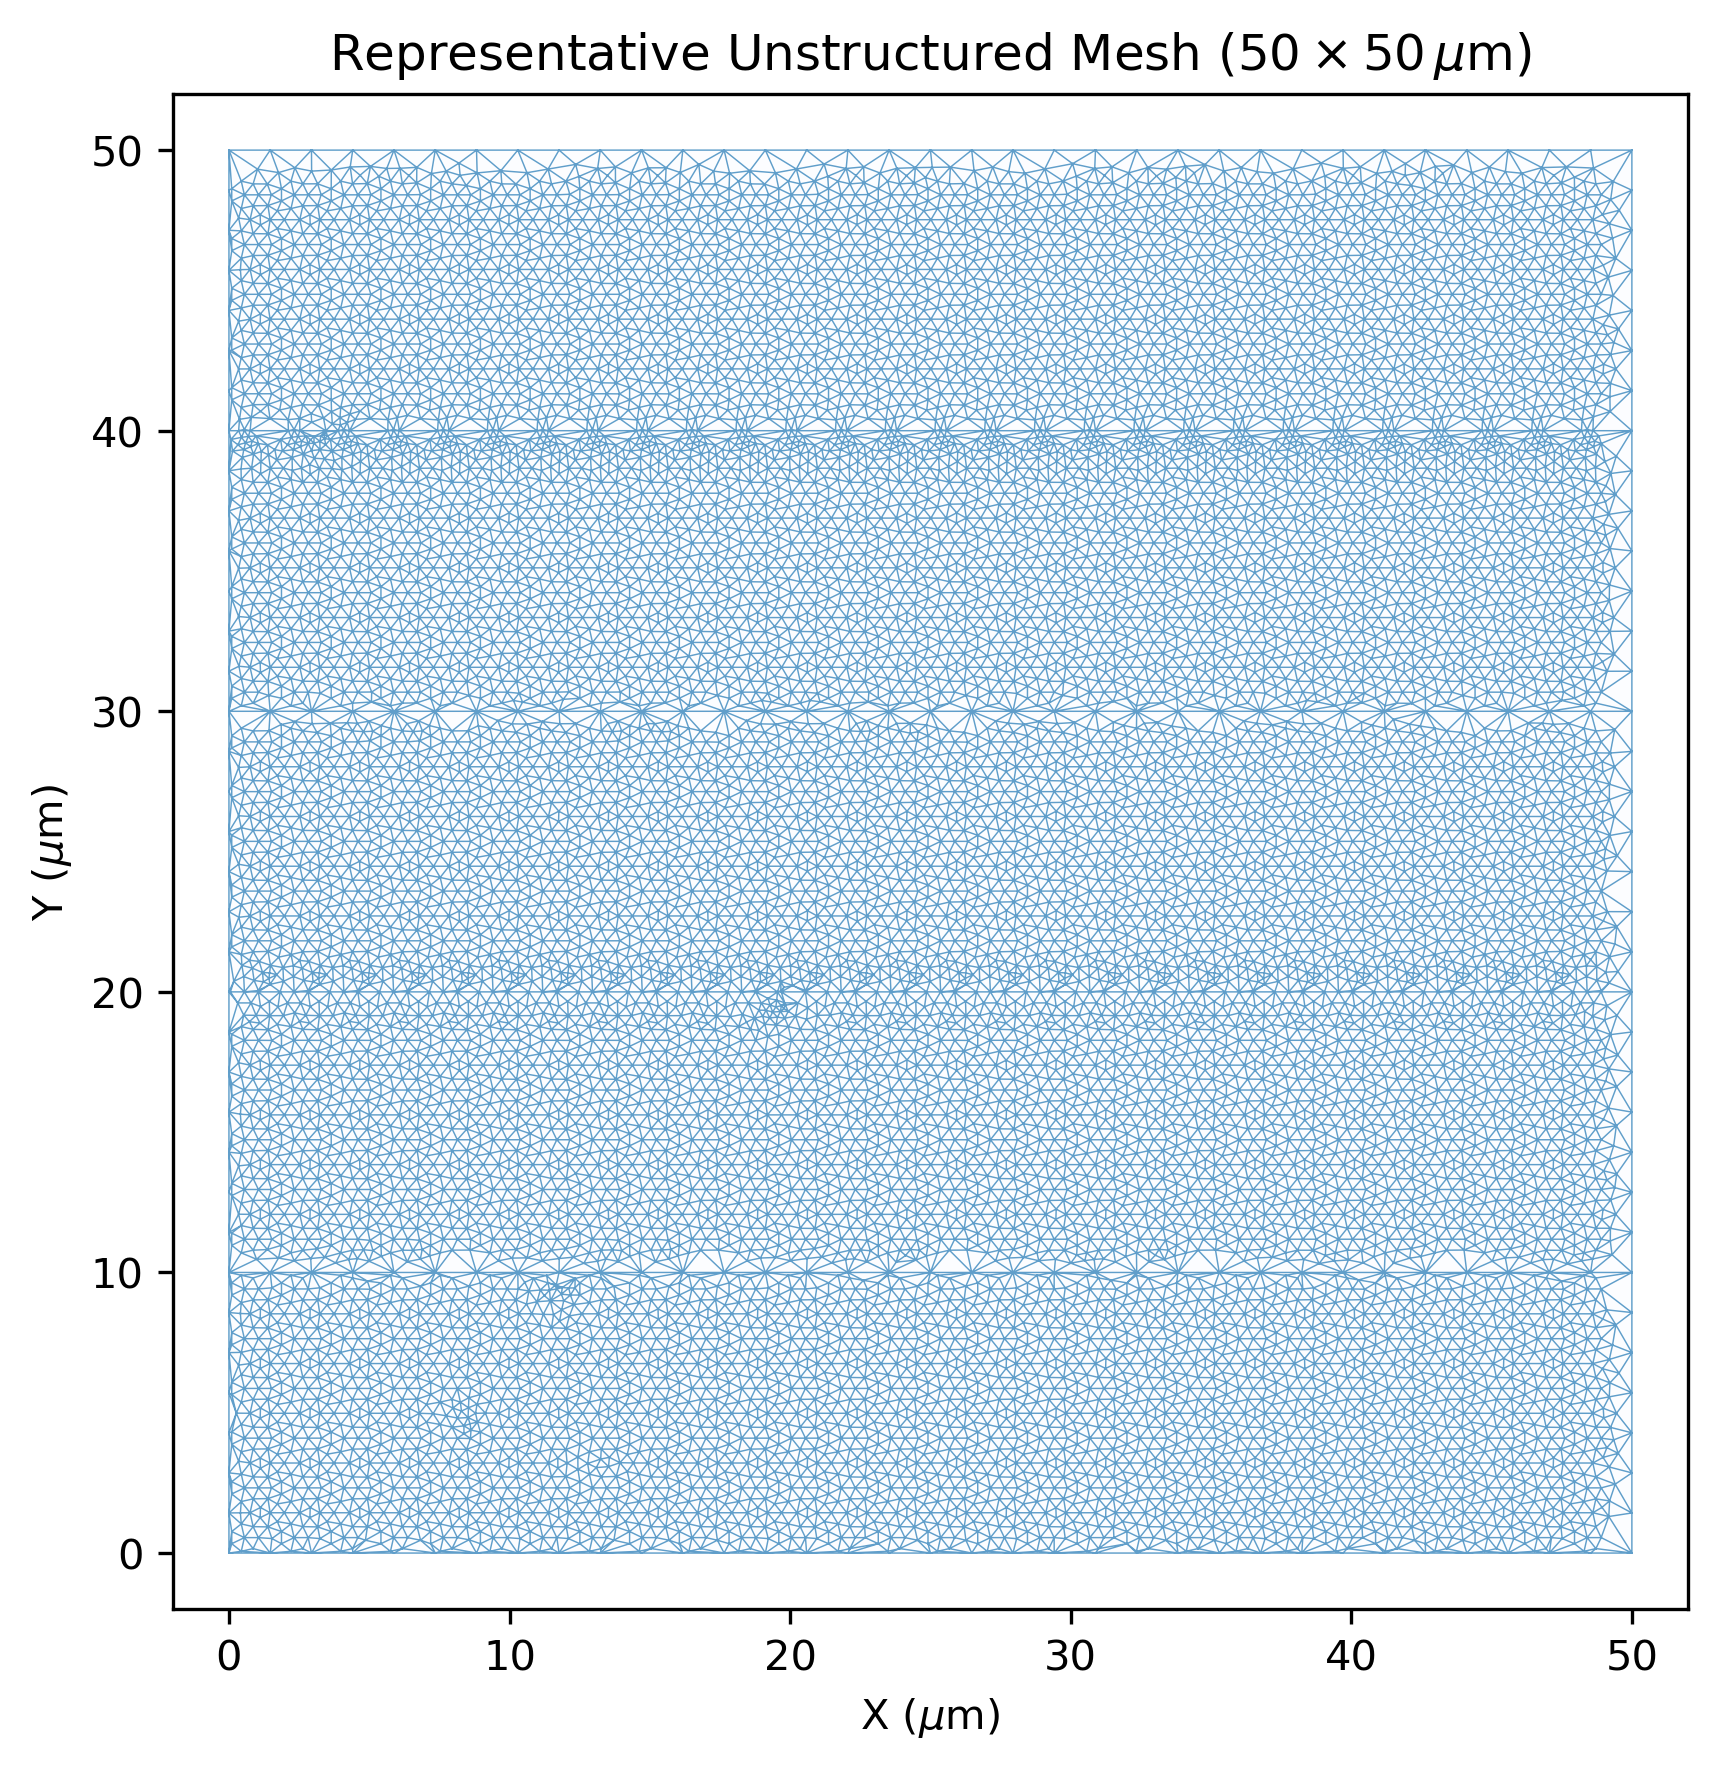

In [10]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# Instantiate 50x50 (L=50, 5 layers * 10 th = 50 W)
sim = Simulator(L=50, Lamina_no=5, th=10, min_length=0.8, max_length=1.5)
mesh = sim.Geometry(mode="mixed")

# 2D geometry points & elements
points = mesh.points[:, :2]
triangles = mesh.cells_dict["triangle"]

# Create elements
triangulation = tri.Triangulation(points[:, 0], points[:, 1], triangles)

# Plot FE mesh
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Filled blue triangles
ax.tripcolor(triangulation, facecolors=[0]*len(triangles), cmap='Blues', alpha=0.25)
ax.triplot(triangulation, color='#1f77b4', linewidth=0.35, alpha=0.7)

ax.set_xlabel(r'X ($\mu$m)')
ax.set_ylabel(r'Y ($\mu$m)')
ax.set_title(r'Representative Unstructured Mesh ($50 \times 50\,\mu\text{m}$)')

ax.set_xlim(-2, 52)
ax.set_ylim(-2, 52)
ax.set_aspect('equal')
plt.tight_layout()

plt.savefig('mesh_example.png', dpi=300)
plt.show()

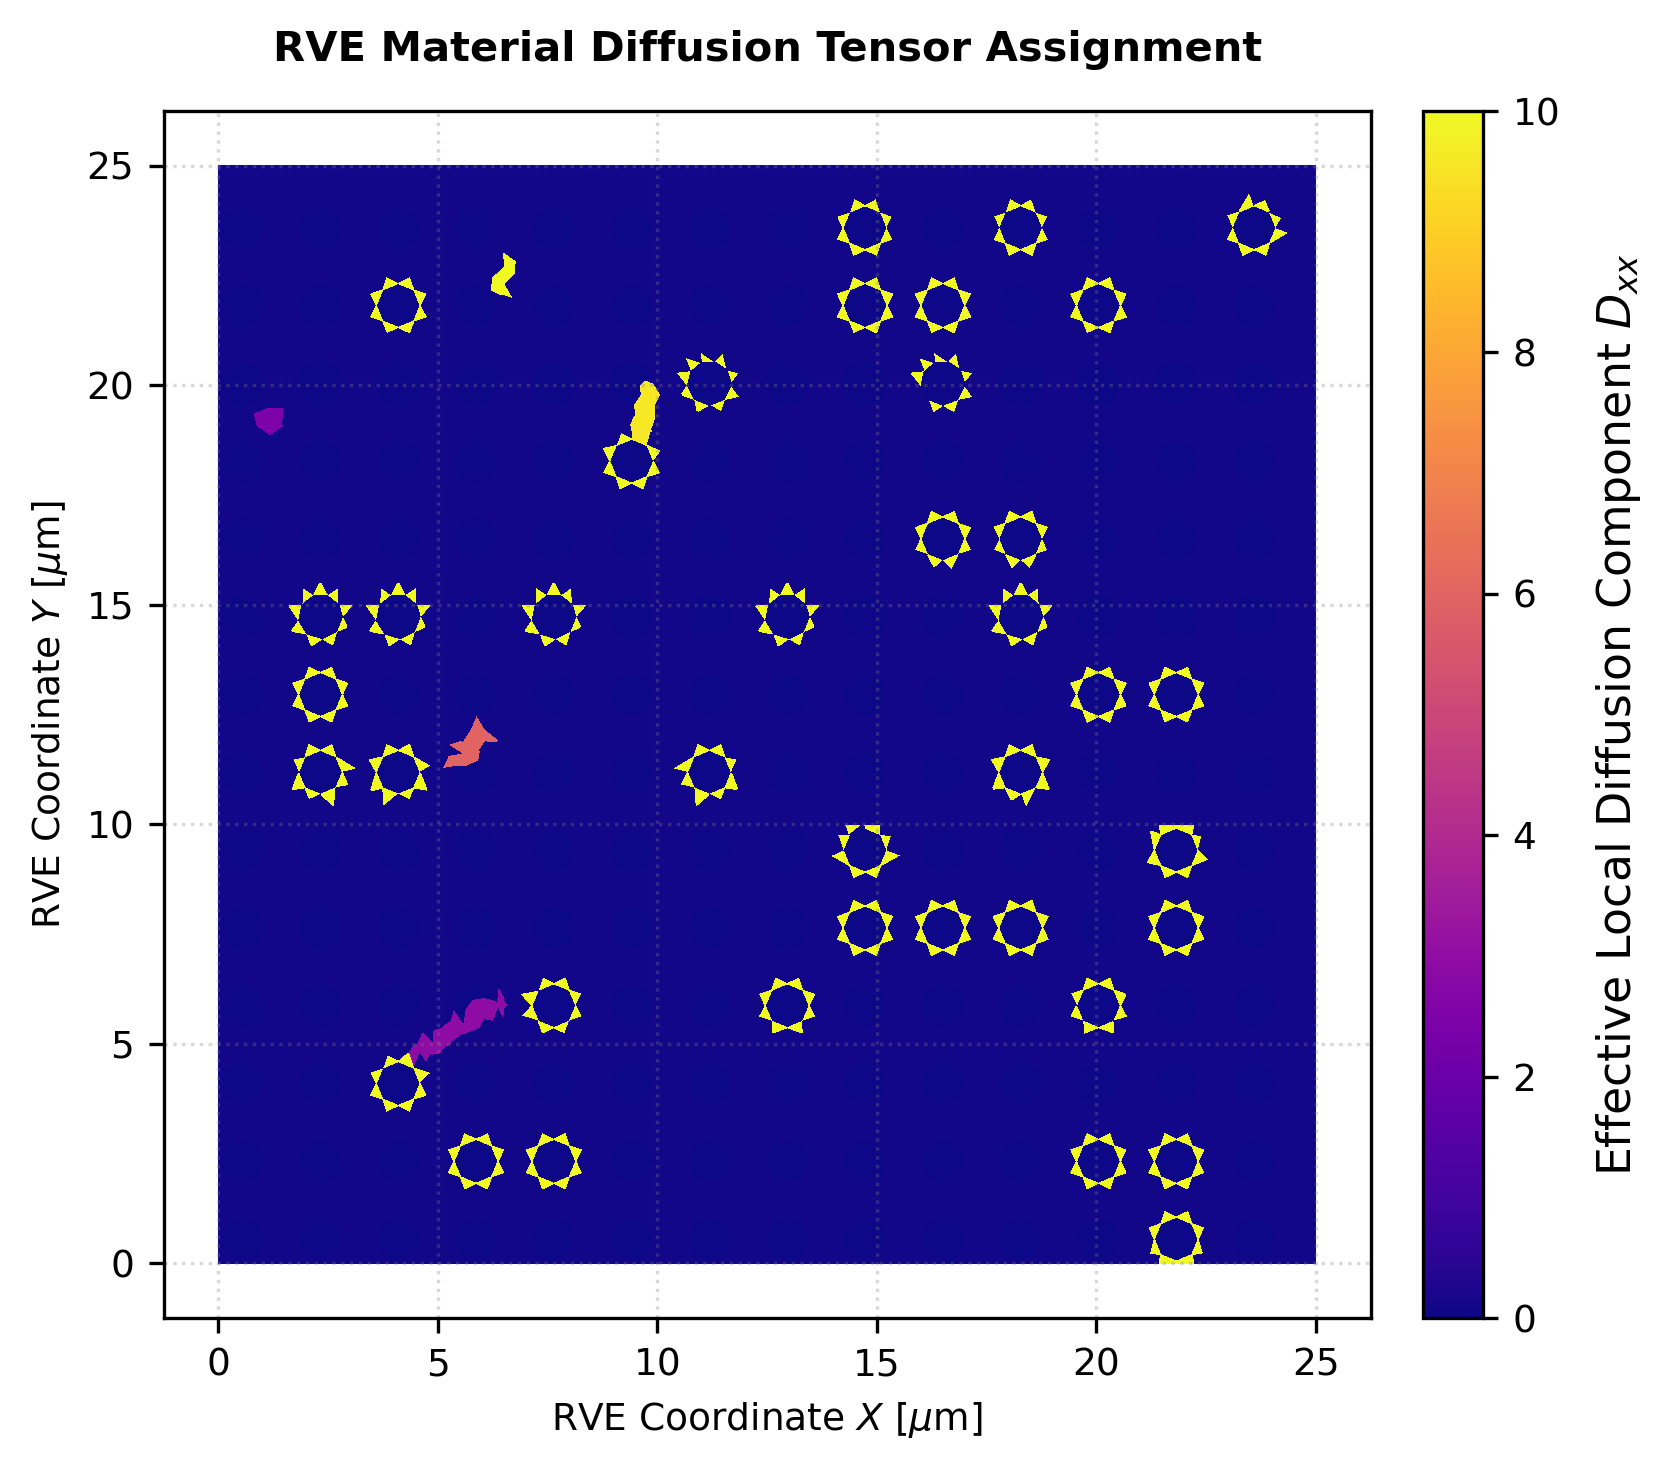

In [51]:
if __name__ == "__main__":
    sim = Simulator(crc_no=5, debond_fraction=0.2)
    points, triangles, elements_D = sim.run_diffusion(mode="mixed")
    
    fig, ax = plt.subplots(figsize=(9, 5), dpi=300) # Professional crisp DPI
    
    # elements colored by the D_00 tensor component
    trip = ax.tripcolor(
        points[:, 0], points[:, 1], triangles, 
        facecolors=elements_D[:, 1, 1], 
        cmap='plasma',
        edgecolors='none'
    )
    
    # Add a colorbar
    cbar = fig.colorbar(trip, ax=ax, aspect=20, pad=0.02)
    cbar.set_label(r'Effective Local Diffusion Component $D_{xx}$', fontsize=11, labelpad=8)
    cbar.ax.tick_params(labelsize=9)
    
    ax.set_xlabel(r'RVE Coordinate $X$ [$\mu$m]', fontsize=9)
    ax.set_ylabel(r'RVE Layers Coordinate [$\mu$m]', fontsize=9)
    ax.set_title("Microstructural Diffusion of Damaged Zone", fontsize=10, pad=12, weight='bold')
    
    ax.set_aspect('equal')
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(True, linestyle=':', alpha=0.3, color='gray')
    
    fig.tight_layout()
    plt.savefig('rve_tensor_mapping.png', bbox_inches='tight', dpi=300)
    plt.show()